<a href="https://colab.research.google.com/github/Lanaanvar/Deep-Learning/blob/main/Set_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Image:


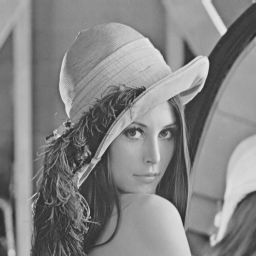

Degraded Image:


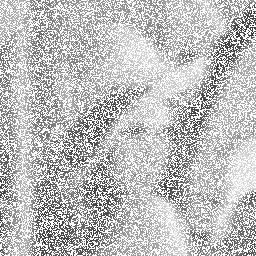

Restored Image (Direct Inverse Filtering):


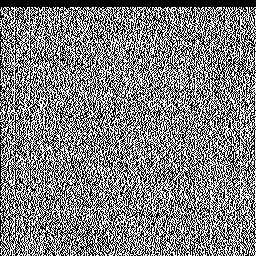

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

img = cv2.imread('lena_img.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    # Resize the image for consistency
    img = cv2.resize(img, (256, 256))
    rows, cols = img.shape

    psf_size = 15
    psf = np.zeros((psf_size, psf_size), np.float32)
    psf[int((psf_size - 1) / 2), :] = 1
    psf = psf / psf_size # Normalize

    degraded_img = cv2.filter2D(img, -1, psf, borderType=cv2.BORDER_REPLICATE)

    # Add some noise (e.g., Gaussian noise)
    mean = 0
    stddev = 10
    noise = np.random.normal(mean, stddev, degraded_img.shape).astype('uint8')
    degraded_img = cv2.add(degraded_img, noise) # Add noise


    # Direct Inverse Filtering

    # Get optimal DFT size for padding
    nrows = cv2.getOptimalDFTSize(rows + psf_size - 1)
    ncols = cv2.getOptimalDFTSize(cols + psf_size - 1)

    # Pad the degraded image and PSF to the optimal size
    padded_degraded_img = cv2.copyMakeBorder(degraded_img, 0, nrows - degraded_img.shape[0], 0, ncols - degraded_img.shape[1], cv2.BORDER_CONSTANT, value=0)
    padded_psf = cv2.copyMakeBorder(psf, 0, nrows - psf_size, 0, ncols - psf_size, cv2.BORDER_CONSTANT, value=0)


    # Perform DFT on the padded degraded image and PSF
    dft_degraded = cv2.dft(np.float32(padded_degraded_img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_psf = cv2.dft(np.float32(padded_psf), flags=cv2.DFT_COMPLEX_OUTPUT)

    epsilon = 1e-6
    dft_psf_magnitude_sq = dft_psf[:,:,0]**2 + dft_psf[:,:,1]**2
    inverse_dft_psf = dft_psf / (dft_psf_magnitude_sq[:,:,np.newaxis] + epsilon)


    restored_dft = np.zeros_like(dft_degraded)
    restored_dft[:,:,0] = dft_degraded[:,:,0] * inverse_dft_psf[:,:,0] - dft_degraded[:,:,1] * inverse_dft_psf[:,:,1]
    restored_dft[:,:,1] = dft_degraded[:,:,0] * inverse_dft_psf[:,:,1] + dft_degraded[:,:,1] * inverse_dft_psf[:,:,0]


    # Perform inverse DFT
    restored_img = cv2.idft(restored_dft, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Crop the restored image back to original size
    restored_img = restored_img[0:rows, 0:cols]

    # Clip values to the valid range [0, 255] and convert to uint8
    restored_img = np.clip(restored_img, 0, 255).astype('uint8')


    # Display the results
    print("Original Image:")
    cv2_imshow(img)

    print("Degraded Image:")
    cv2_imshow(degraded_img)

    print("Restored Image (Direct Inverse Filtering):")
    cv2_imshow(restored_img)

Original Image:


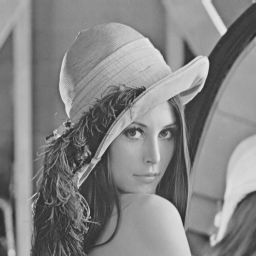

Degraded Image:


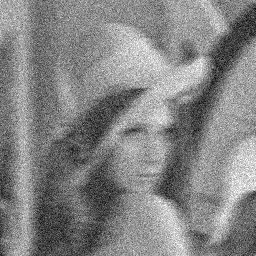

Restored Image (Wiener - Constant Ratio):


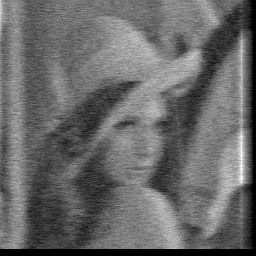

Restored Image (Wiener - Autocorrelation):


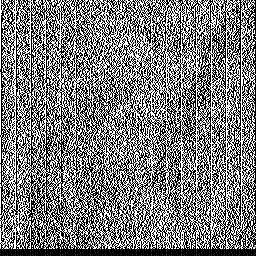

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Load a sample image (assuming 'lena_img.png' or 'image1.jpg' exists and resize it)
img = cv2.imread('lena_img.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    # Resize the image for consistency
    img = cv2.resize(img, (256, 256))
    rows, cols = img.shape

    psf_size = 15
    psf = np.zeros((psf_size, psf_size), np.float32)
    psf[int((psf_size - 1) / 2), :] = 1
    psf = psf / psf_size # Normalize

    degraded_img = cv2.filter2D(img, -1, psf, borderType=cv2.BORDER_REPLICATE)

    mean = 0
    stddev = 20
    noise = np.random.normal(mean, stddev, degraded_img.shape)
    degraded_img = cv2.add(degraded_img.astype(np.float32), noise.astype(np.float32))
    degraded_img = np.clip(degraded_img, 0, 255).astype('uint8')


    # Wiener Filtering

    # Get optimal DFT size for padding
    nrows = cv2.getOptimalDFTSize(rows + psf_size - 1)
    ncols = cv2.getOptimalDFTSize(cols + psf_size - 1)

    # Pad the degraded image and PSF to the optimal size
    padded_degraded_img = cv2.copyMakeBorder(degraded_img, 0, nrows - degraded_img.shape[0], 0, ncols - degraded_img.shape[1], cv2.BORDER_CONSTANT, value=0)
    padded_psf = cv2.copyMakeBorder(psf, 0, nrows - psf_size, 0, ncols - psf_size, cv2.BORDER_CONSTANT, value=0)


    # Perform DFT on the padded degraded image and PSF
    dft_degraded = cv2.dft(np.float32(padded_degraded_img), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_psf = cv2.dft(np.float32(padded_psf), flags=cv2.DFT_COMPLEX_OUTPUT)

    # Calculate the magnitude squared of the PSF in the frequency domain
    dft_psf_magnitude_sq = dft_psf[:,:,0]**2 + dft_psf[:,:,1]**2

    noise_variance = stddev**2

    # Estimate image variance (variance of the original image)
    image_variance = np.var(img)

    # Calculate the constant ratio K
    K = noise_variance / image_variance if image_variance > 0 else 1e-6 # Avoid division by zero

    # Wiener filter in the frequency domain (constant ratio)
    wiener_filter_constant = dft_psf.copy()
    # Conjugate of H is H[:,:,0] - i * H[:,:,1]
    wiener_filter_constant[:,:,1] *= -1 # Take conjugate

    # Calculate the denominator: |H|^2 + K
    denominator_constant = dft_psf_magnitude_sq + K

    # Avoid division by zero
    denominator_constant[denominator_constant == 0] = 1e-6

    # Divide H* by (|H|^2 + K)
    wiener_filter_constant[:,:,0] /= denominator_constant
    wiener_filter_constant[:,:,1] /= denominator_constant

    # Multiply with the degraded image DFT
    restored_dft_constant = np.zeros_like(dft_degraded)
    restored_dft_constant[:,:,0] = dft_degraded[:,:,0] * wiener_filter_constant[:,:,0] - dft_degraded[:,:,1] * wiener_filter_constant[:,:,1]
    restored_dft_constant[:,:,1] = dft_degraded[:,:,0] * wiener_filter_constant[:,:,1] + dft_degraded[:,:,1] * wiener_filter_constant[:,:,0]


    # Perform inverse DFT for constant ratio Wiener filtering
    restored_img_constant = cv2.idft(restored_dft_constant, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Crop and clip
    restored_img_constant = restored_img_constant[0:rows, 0:cols]
    restored_img_constant = np.clip(restored_img_constant, 0, 255).astype('uint8')


    Sn = noise_variance # Assuming white noise

    dft_img = cv2.dft(np.float32(padded_degraded_img), flags=cv2.DFT_COMPLEX_OUTPUT) # Using degraded image DFT for Sf approximation
    Sf = dft_img[:,:,0]**2 + dft_img[:,:,1]**2 + 1e-6 # Add epsilon to avoid division by zero


    # Calculate the ratio Sn(u,v) / Sf(u,v)
    noise_to_signal_ratio_freq = Sn / Sf

    # Wiener filter in the frequency domain (autocorrelation)
    wiener_filter_auto = dft_psf.copy()
    wiener_filter_auto[:,:,1] *= -1 # Take conjugate

    # Calculate the denominator: |H|^2 + Sn/Sf
    denominator_auto = dft_psf_magnitude_sq + noise_to_signal_ratio_freq

    # Avoid division by zero
    denominator_auto[denominator_auto == 0] = 1e-6

    # Divide H* by (|H|^2 + Sn/Sf)
    wiener_filter_auto[:,:,0] /= denominator_auto
    wiener_filter_auto[:,:,1] /= denominator_auto

    # Multiply with the degraded image DFT
    restored_dft_auto = np.zeros_like(dft_degraded)
    restored_dft_auto[:,:,0] = dft_degraded[:,:,0] * wiener_filter_auto[:,:,0] - dft_degraded[:,:,1] * wiener_filter_auto[:,:,1]
    restored_dft_auto[:,:,1] = dft_degraded[:,:,0] * wiener_filter_auto[:,:,1] + dft_degraded[:,:,1] * wiener_filter_auto[:,:,0]

    # Perform inverse DFT for autocorrelation Wiener filtering
    restored_img_auto = cv2.idft(restored_dft_auto, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

    # Crop and clip
    restored_img_auto = restored_img_auto[0:rows, 0:cols]
    restored_img_auto = np.clip(restored_img_auto, 0, 255).astype('uint8')


    # Display the results
    print("Original Image:")
    cv2_imshow(img)

    print("Degraded Image:")
    cv2_imshow(degraded_img)

    print("Restored Image (Wiener - Constant Ratio):")
    cv2_imshow(restored_img_constant)

    print("Restored Image (Wiener - Autocorrelation):")
    cv2_imshow(restored_img_auto)

Original RGB Image:


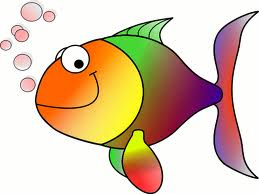

Hue Image:


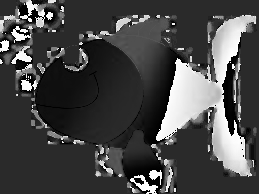

Saturation Image:


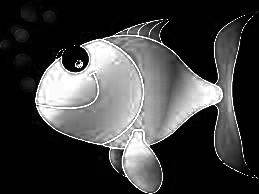

Intensity Image:


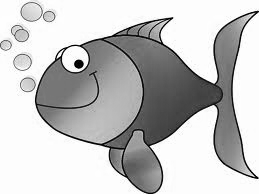

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Load an RGB image (using image1.jpg as an example, assuming it exists)
img_rgb = cv2.imread('image1.jpg', cv2.IMREAD_COLOR)

if img_rgb is None:
    print("Error: image1.jpg not found or could not be loaded.")
else:
    # Convert RGB to HSI manually (OpenCV doesn't have a direct HSI conversion)
    # Normalize pixel values to [0, 1]
    img_normalized = img_rgb.astype(np.float32) / 255.0
    B, G, R = cv2.split(img_normalized)

    # Calculate Intensity (I)
    I = (R + G + B) / 3.0

    # Calculate Saturation (S)
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1 - (3.0 * min_rgb) / (R + G + B + 1e-6) # Add epsilon to avoid division by zero
    S[R + G + B == 0] = 0 # Handle the case where R+G+B is zero

    # Calculate Hue (H)
    denominator = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-6
    theta = np.arccos(((R - G) + (R - B)) / (2 * denominator))

    H = np.degrees(theta)
    H[B > G] = 360 - H[B > G]

    H_display = (H / 360.0 * 255.0).astype('uint8')
    S_display = (S * 255.0).astype('uint8')
    I_display = (I * 255.0).astype('uint8')

    # Display the original and HSI channels
    print("Original RGB Image:")
    cv2_imshow(img_rgb)

    print("Hue Image:")
    cv2_imshow(H_display)

    print("Saturation Image:")
    cv2_imshow(S_display)

    print("Intensity Image:")
    cv2_imshow(I_display)